In [44]:
import os

if 'main_dir' in globals():
    os.chdir(main_dir)

import pandas as pd
from utils.load_config import load_exp_config, get_value_from_fields, get_df_historical_data
from utils.load_data import (
    get_df_from_datetime_range,
    get_mlruns_info
    )
import numpy as np

# %matplotlib inline

if os.getcwd().endswith("notebooks"):
    main_dir = os.getcwd()
    os.chdir("..")

In [45]:
os.getuid()

1000

In [46]:
DECAY_RATE = 1

# Only used for pivot table
# end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop
# end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server
# end_datetime_str = start_datetime_str = "2024-11-13 19-10-58" # Azure2
# end_datetime_str = start_datetime_str = "2024-11-13 20-32-27" # Server

# end_datetime_str = start_datetime_str = "2024-11-13 22-48-46" # Server
# end_datetime_str = start_datetime_str = "2024-11-14 01-18-39" # Server

# Range
start_datetime_str = "2024-11-14 16-28-43"
end_datetime_str = "2024-11-19 05-46-17"
# end_datetime_str = "2024-11-19 05-46-17"

df, actor_df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False,
                                # backup_dir="/media/tcc/F89F-5CC1/ICLR/backup-data"
                                )

In [47]:
def extract_columns(row):
    scenario = row.exp_config["scenario"]["_target_"].split(".")[-1]
    is_reset_buffer = row.exp_config["scenario"]["reset_rb_each_task"]
    buffer_size = row.exp_config["scenario"]["buffer_size"]
    learning_starts = row.exp_config["scenario"]["learning_starts"]
    controller = "SAC" if "sac" in scenario.lower() else "TD3"
    category = scenario[:scenario.find(controller)]
    seed = row.exp_config["seed"]
    return category, controller, is_reset_buffer, buffer_size, learning_starts, seed
    
    # return pd.Series(data=[category, controller, is_reset_buffer, buffer_size], 
    #                  index=["category", "controller", "is_reset_buffer", "buffer_size"])

def preprocess_df(df):
    df = df.reindex()

    tmp = df.apply(extract_columns, axis=1, result_type='expand')
    # tmp = df.exp_config.apply(extract_columns)
    tmp.columns = ["category", "controller", "is_reset_buffer", "buffer_size", "learning_starts", "seed"]
    df = pd.concat([df, tmp], axis=1)

    df = df.sort_values(["experiment_path", "iteration_id", "step_id"])
    df["trained_task"] = df.loc[:, ["task_name", "phase"]].apply(lambda row: row.task_name if row.phase == "train" else pd.NA, axis=1)
    df["trained_task"] = df.trained_task.fillna(method='ffill')
    return df

df = df.drop(columns=[c for c in df.columns if "pixel" in c.lower()])
df = preprocess_df(df)

/tmp/ipykernel_635795/839880941.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [48]:
# Range
start_datetime_str = "2024-11-19 06-51-35"
end_datetime_str = "2024-11-20 07-43-23"

tmp_df, tmp_actor_df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False,
                                # back
                                )
tmp_df = tmp_df.drop(columns=[c for c in tmp_df.columns if "pixel" in c.lower()])
tmp_df = preprocess_df(tmp_df)

df = pd.concat([df, tmp_df])
actor_df = pd.concat([actor_df, tmp_actor_df])

/tmp/ipykernel_635795/839880941.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [49]:
# Range
start_datetime_str = "2024-11-20 11-07-45"
end_datetime_str = "2024-11-20 11-11-06"

tmp_df, tmp_actor_df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False,
                                # back
                                )
tmp_df = tmp_df.drop(columns=[c for c in tmp_df.columns if "pixel" in c.lower()])
tmp_df = preprocess_df(tmp_df)

df = pd.concat([df, tmp_df])
actor_df = pd.concat([actor_df, tmp_actor_df])

/tmp/ipykernel_635795/839880941.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [50]:
backup_df = df.copy()
backup_actor_df = actor_df.copy()

In [51]:
df = backup_df.copy()
actor_df = backup_actor_df.copy()

# Only used for pivot table
# Large in turn are LF, RP, PO
end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop cp ckpt
end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server cp ckpt
end_datetime_str = start_datetime_str = "2024-11-13 22-48-46" # Server

# Small in turn are LF, RP, PO
# end_datetime_str = start_datetime_str = "2024-11-13 19-10-58" # Azure2 cp ckpt
# end_datetime_str = start_datetime_str = "2024-11-13 20-32-27" # Server
# end_datetime_str = start_datetime_str = "2024-11-14 01-18-39" # Server

ref_df, ref_actor_df = get_df_from_datetime_range(start_datetime_str, 
                                end_datetime_str, 
                                decay_rate=DECAY_RATE,
                                max_iter=np.inf,
                                validity_check=False,
                                reload=False,
                                backup_dir="/home/robosrv/huyhoang/iclr-2025/backup-data-SAC-gazebo-exp/backup-data"
                                )

# ref_actor_df = get_mlruns_info(start_datetime_str, 
#                                end_datetime_str,
#                                reload=False,)
if "experiment_path" not in ref_actor_df.columns:
    ref_actor_df["experiment_path"] = ref_df.experiment_path.values[0]

ref_df = preprocess_df(ref_df)

/tmp/ipykernel_635795/839880941.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [76]:
df = backup_df.copy()
actor_df = backup_actor_df.copy()

# Only used for pivot table
# Large in turn are LF, RP, PO
end_datetime_str = start_datetime_str = "2024-11-13 17-38-28" # Laptop cp ckpt
end_datetime_str = start_datetime_str = "2024-11-13 18-25-28" # Server cp ckpt
end_datetime_str = start_datetime_str = "2024-11-13 22-48-46" # Server

# cherry pick
cherry_pick = [
    "2024-11-13 19-10-58", # LF
    "2024-11-19 00-53-17", # 
]

cp_df = pd.DataFrame()

for e in cherry_pick:
    end_datetime_str = start_datetime_str = e
    tmp_cp_df, _ = get_df_from_datetime_range(start_datetime_str, 
                                    end_datetime_str, 
                                    decay_rate=DECAY_RATE,
                                    max_iter=np.inf,
                                    validity_check=False,
                                    reload=False,
                                    backup_dir="/home/robosrv/huyhoang/iclr-2025/backup-data-SAC-gazebo-exp/backup-data"
                                    )
    
    cp_df = pd.concat([cp_df, tmp_cp_df])

cp_df = preprocess_df(cp_df)

Load mlruns_folder_info: 603
Load path: 1 {'/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17': ['/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00049.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_02438.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_00060.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_01876.h5', '/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/regelum_data/outputs/2024-11-19/00-53-17/0/.callbacks/GZHistoricalDataCallback/observations_actions_it_03588.

Output()

/tmp/ipykernel_635795/839880941.py:24: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["trained_task"] = df.trained_task.fillna(method='ffill')


In [77]:
############################### Robot Pursuit is misisng ###############################
# group_df = df.groupby(["controller", "category", "task_name", "is_reset_buffer"]).last()
group_df = df.groupby(["controller", "category", "buffer_size"]).last()
group_df

time  running_objective current_value  \
controller category      buffer_size                                           
SAC        LineFollowing 5000         4.620           0.979592          None   
                         20000        4.620           0.000000          None   
           PushingObject 5000         0.660          10.000000          None   
                         20000        0.660           0.477612          None   
           RobotPursuit  5000         2.145          10.000000          None   
                         20000        2.343          10.000000          None   

                                      current_undiscounted_value  episode_id  \
controller category      buffer_size                                           
SAC        LineFollowing 5000                          27.673469           1   
                         20000                         20.244898           1   
           PushingObject 5000                          13.800000           1   
                         20000                          2.922484           1   
           RobotPursuit  5000                          19.712128           1   
                         20000                         21.209820           1   

                                      iteration_id        task_name  step_id  \
controller category      buffer_size                                           
SAC        LineFollowing 5000                 1040    circle_yellow      899   
                         20000                1054    circle_yellow      899   
           PushingObject 5000                 3636           yellow      179   
                         20000                3800           yellow      191   
           RobotPursuit  5000                 1967  yellow_cylinder      460   
                         20000                2251  yellow_cylinder      459   

                                     phase  exploration  \
controller category      buffer_size                      
SAC        LineFollowing 5000         eval        False   
                         20000        eval        False   
           PushingObject 5000         eval        False   
                         20000        eval        False   
           RobotPursuit  5000         eval        False   
                         20000        eval        False   

                                                                         robot_position  \
controller category      buffer_size                                                      
SAC        LineFollowing 5000         [20.000000000294538, 1.3648712227144438e-10, -...   
                         20000        [20.000000000296666, 1.378124010063652e-10, -7...   
           PushingObject 5000         [0.40000000077955206, -4.000000000067829, -0.0...   
                         20000        [0.4000000007637304, -4.000000000069541, -0.05...   
           RobotPursuit  5000         [-1.199999999222664, -2.0789801963430133e-10, ...   
                         20000        [-1.1999999992052033, -2.1267470257956326e-10,...   

                                      Linear Velocity [m/s]  \
controller category      buffer_size                          
SAC        LineFollowing 5000                      0.200000   
                         20000                     0.200000   
           PushingObject 5000                      1.190015   
                         20000                     1.188007   
           RobotPursuit  5000                      1.186670   
                         20000                     1.196061   

                                      Angular Velocity [rad/s]  \
controller category      buffer_size                             
SAC        LineFollowing 5000                         0.818860   
                         20000                       -1.485878   
           PushingObject 5000                        -0.128561   
                         20000                       -4.637330   
           Ro

In [78]:
df.loc[:, ["controller", "category", "buffer_size", "seed"]].groupby(["controller", "category", "buffer_size"]).nunique()

seed
controller category      buffer_size      
SAC        LineFollowing 5000           32
                         20000          33
           PushingObject 5000           32
                         20000          38
           RobotPursuit  5000           32
                         20000          34

In [79]:
"\t".join([f"{a}:{b}" for a, b in list(zip(group_df.index.names, group_df.index[0]))])
# list(zip(group_df.index.names, group_df.index[0]))
group_df.index

MultiIndex([('SAC', 'LineFollowing',  5000),
            ('SAC', 'LineFollowing', 20000),
            ('SAC', 'PushingObject',  5000),
            ('SAC', 'PushingObject', 20000),
            ('SAC',  'RobotPursuit',  5000),
            ('SAC',  'RobotPursuit', 20000)],
           names=['controller', 'category', 'buffer_size'])

In [80]:
df = df.reset_index().set_index(group_df.index.names)
ref_df = ref_df.reset_index().set_index(group_df.index.names)

In [81]:
group_df.index[0] in ref_df.index
group_df.index[0] == ref_df.index.values[0]
group_df.index[1], ref_df.index.values[0]

ref_df.loc[:, ["iteration_id", "experiment_path", "experiment_path"]]


print("actor len:", len(actor_df))
print("df len:", len(df))
# tmp = pd.concat([
# actor_df.reset_index().set_index('experiment_path'),
# df.reset_index().set_index('experiment_path').loc[:, ["controller", "category", "buffer_size"]],
# ],
# join="inner")

tmp = actor_df.reset_index().set_index('experiment_path').join(
    df.reset_index().loc[:, ["controller", "category", "buffer_size", "experiment_path"]].groupby("experiment_path").last(),
    how="inner"
)

actor_df = tmp.reset_index().set_index(group_df.index.names)

actor len: 39104
df len: 5219100


In [82]:
actor_df.index.unique()

MultiIndex([('SAC', 'PushingObject',  5000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'LineFollowing',  5000),
            ('SAC',  'RobotPursuit', 20000),
            ('SAC',  'RobotPursuit',  5000),
            ('SAC', 'LineFollowing', 20000)],
           names=['controller', 'category', 'buffer_size'])

In [83]:
actor_df["steps"] = [100 * i for i in range((len(ref_actor_df)))] * actor_df.run_name.nunique()

In [84]:
from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvelica']})
# for Palatino and other serif fonts use:
# rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=False)

In [85]:
import matplotlib
print(matplotlib.matplotlib_fname())
matplotlib.__version__

/home/robosrv/huyhoang/iclr-2025/regelum-playground-iclr/venv/lib/python3.11/site-packages/matplotlib/mpl-data/matplotlibrc


'3.9.2'

# Graph

HERE ('SAC', 'PushingObject', 20000)


/tmp/ipykernel_635795/3924877837.py:139: PerformanceWarning: indexing past lexsort depth may impact performance.
  actor_df.loc[id],


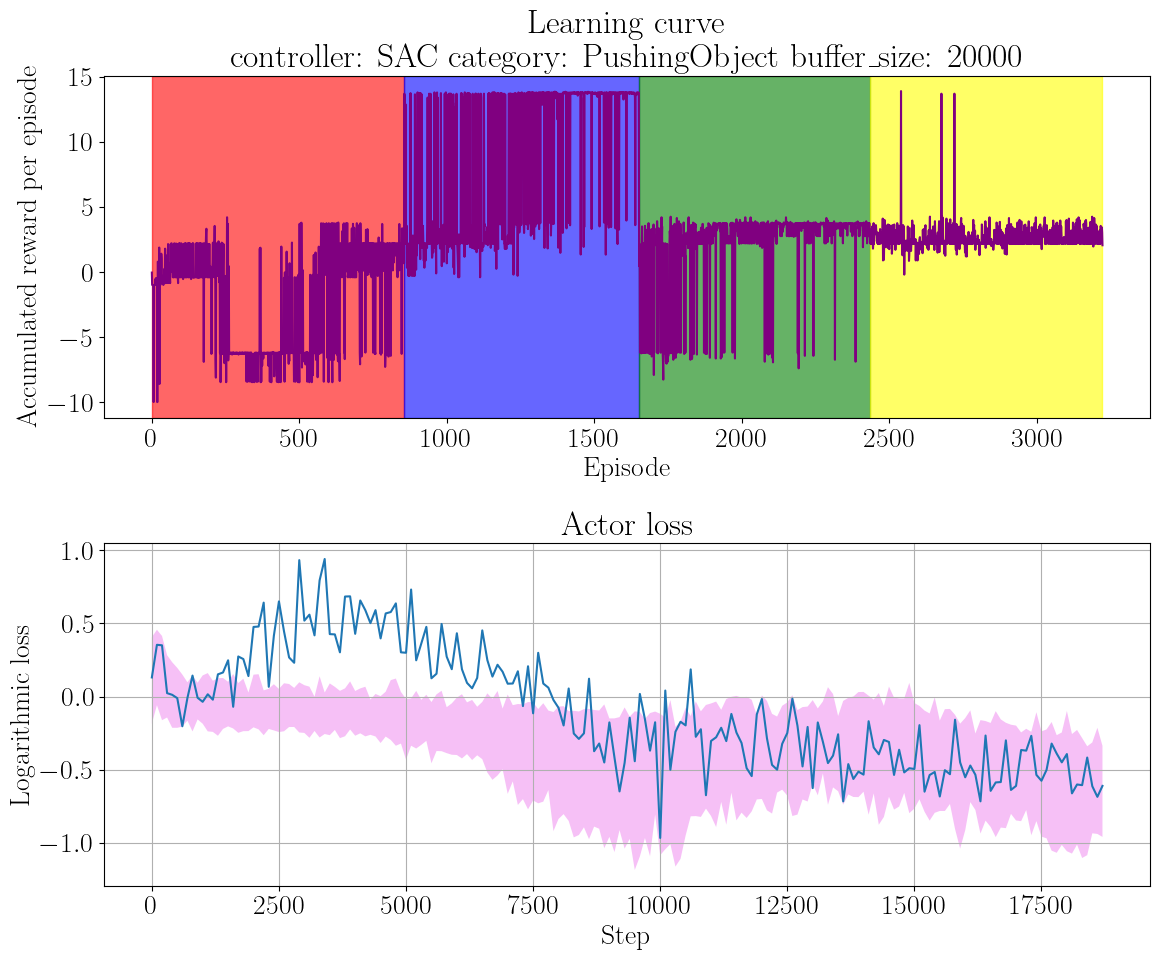

In [86]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 20
})
# import matplotlib
# %matplotlib inline

N_SAMPLE_INTER=1000

def interpolate(X_, Y_):
    degree = 30
    coeffs = np.polyfit(X_, Y_, degree)
    X_ = np.linspace(X_.min(), X_.max(), N_SAMPLE_INTER)
    Y_ = np.polyval(coeffs, X_)

    return X_, Y_


def plot_cost_ic_learning_curve_mod(df, 
                                    ax, 
                                    low_quantile=0.025, 
                                    high_quantile=0.975, 
                                    color=None, 
                                    use_interpolate=False):
    def quantile_low(series):
        return series.quantile(low_quantile)

    def quantile_high(series):
        return series.quantile(high_quantile)

    group_df = df.loc[:, 
                      ["experiment_path", "steps", "actor_loss"]
                      ].groupby(["experiment_path", "steps"]).last()
    
    ic_95_df = group_df.groupby("steps").agg({"actor_loss": [quantile_low, quantile_high]})

    # Plot
    if not use_interpolate:
        X_ = ic_95_df.index
        Y_hi = ic_95_df.actor_loss.quantile_high
        Y_lo = ic_95_df.actor_loss.quantile_low
    else:
        cubic_interpolation_model_hi = interpolate(
            ic_95_df.index, 
            ic_95_df.actor_loss.quantile_high.values, 
            )
        
        cubic_interpolation_model_lo = interpolate(
            ic_95_df.index, 
            ic_95_df.actor_loss.quantile_low.valuess, 
            )
    
        # Plotting the Graph
        X_=np.linspace(ic_95_df.index.min(), ic_95_df.index.max(), N_SAMPLE_INTER)
        Y_hi=cubic_interpolation_model_hi(X_)
        Y_lo=cubic_interpolation_model_lo(X_)
    
    p = ax.fill_between(X_, 
                        Y_hi, Y_lo, 
                        facecolor=color,
                        alpha=0.5)
    
    return p

def plot_learning_curve(index, index_names, df, title="Learning curve", ax=None, use_interpolate=False):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10,3))

    df = df.reset_index().set_index(index_names)
    tmp_df = df.loc[index]

    # Filter exploration actions
    tmp_df = tmp_df.loc[:, ["iteration_id", "step_id", "task_name", "current_undiscounted_value", "learning_starts", "phase"]]
    tmp_df = tmp_df[np.invert(np.logical_and(tmp_df.phase == "train", tmp_df.step_id <= tmp_df.learning_starts))]
    tmp_group_df = tmp_df.groupby("iteration_id")

    tmp_group_df = tmp_group_df.aggregate({
        "current_undiscounted_value": "last", 
        "task_name": "last",
        "step_id": "last"
        })
    
    # Re-assign index for ploting
    tmp_group_df = tmp_group_df.reset_index()
    tmp_group_df.iteration_id = tmp_group_df.reset_index().index

    if not use_interpolate:
        tmp_group_df = tmp_group_df.set_index("iteration_id")
        tmp_group_df.plot(y="current_undiscounted_value", ax=ax, color="purple")
    else:
        ax.plot(*interpolate(tmp_group_df.iteration_id, tmp_group_df.current_undiscounted_value), color="purple")
        

    colors = ["red", "blue", "green", "yellow"]
    for t in tmp_group_df.task_name.unique():
        for c in colors:
            if c in t.lower():
                break

        tmp = tmp_group_df.reset_index().set_index("task_name").loc[t]
        ax.axvspan(tmp.iteration_id.values[0], tmp.iteration_id.values[-1], alpha=0.6, color=c)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Accumulated reward per episode')
    ax.set_title(
        f'{title}\n' + 
        "   ".join([f"{a}: {b}" for a, b in list(zip(index_names, index))])
    )
    legend = ax.legend()
    legend.remove()

    return "_".join([f"{a}_{b}" for a, b in list(zip(index_names, index))]) + "_interp_{}".format(1 if use_interpolate else 0)


for id in group_df.index:
    if id not in ref_df.index:
        continue

    print("HERE", id)
    for interp in [False]:
    # for interp in [True, False]:
        fig, ax = plt.subplots(2, 1, figsize=(12, 10))
        title = plot_learning_curve(id, 
                                    group_df.index.names, 
                                    ref_df[ref_df.phase=="train"], 
                                    ax=ax[0],
                                    use_interpolate=interp)
        
        ref_actor_df["steps"] = [100 * i for i in range(len(ref_actor_df))]
        (
            ref_actor_df[ref_actor_df.experiment_path == \
                         ref_df.experiment_path.values[0]]
            ).plot(x="steps", y="actor_loss", ax=ax[1])
        
        plot_cost_ic_learning_curve_mod(
            actor_df.loc[id],
            ax=ax[1],
            color="violet"
        )
        
        ax[1].set_title("Actor loss")
        ax[1].set_ylabel("Logarithmic loss")
        ax[1].set_xlabel("Step")
        ax[1].legend().remove()
        ax[1].grid()
        
        plt.tight_layout()
        os.makedirs("./media", exist_ok=True)
        fig.savefig("./media/{}.pdf".format(title))

In [87]:
group_df.index
ref_df.index

MultiIndex([('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ...
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000),
            ('SAC', 'PushingObject', 20000)],
           names=['controller', 'category', 'buffer_size'], length=21802)

In [88]:
ref_actor_df

,time,actor_loss,step_id,run_name,experiment_path,steps
0,1731538237333,0.130507,300,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,0
1,1731538274294,0.353728,400,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,100
2,1731538314107,0.350285,500,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,200
3,1731538361182,0.023070,600,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,300
4,1731538406203,0.011740,700,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,400
...,...,...,...,...,...,...
183,1731546620329,-0.606178,4500,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,18300
184,1731546662496,-0.417155,4600,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,18400
185,1731546704202,-0.613539,4700,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,18500
186,1731546744696,-0.686051,4800,2024-11-13 22-48-46 0,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,18600


In [89]:
df[df.phase=="train"].set_index("iteration_id").current_undiscounted_value.values[-30:]

array([14.53061224, 14.97959184, 15.34693878, 15.75510204, 16.20408163,
       16.65306122, 17.14285714, 17.63265306, 18.24489796, 18.97959184,
       19.83673469, 20.81632653, 21.59183673, 22.36734694,  0.53061224,
        1.06122449,  1.59183673,  2.12244898,  2.6122449 ,  3.18367347,
        3.83673469,  4.57142857,  5.46938776,  6.44897959,  7.34693878,
        8.20408163,  9.06122449,  9.95918367, 10.93877551, 11.87755102])

In [90]:
df = df.reset_index()
df[df.iteration_id==1]

,controller,category,buffer_size,index,time,running_objective,current_value,current_undiscounted_value,episode_id,iteration_id,...,robot_position,Linear Velocity [m/s],Angular Velocity [rad/s],absolute_path,exp_config,experiment_path,is_reset_buffer,learning_starts,seed,trained_task
0,SAC,PushingObject,20000,0,0.000,0.500000,None,0.500000,1,1,...,"[0.47245949647877583, 0.015633680565440393, -0...",1.077256,12.528983,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,20,red
1,SAC,PushingObject,20000,1,0.000,0.000000,None,0.500000,1,1,...,"[0.5535773829162759, 0.03216475836566404, -0.0...",0.979005,-14.851533,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,20,red
2,SAC,PushingObject,20000,2,0.165,0.000000,None,0.500000,1,1,...,"[0.6176444176943888, 0.0559227592126856, -0.05...",0.830109,-3.882210,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,20,red
3,SAC,PushingObject,20000,3,0.330,-1.000000,None,-0.500000,1,1,...,"[0.40000000005476616, 6.472603363159497e-11, -...",0.622213,5.054447,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,20,red
21854,SAC,LineFollowing,20000,0,0.000,0.734694,None,0.734694,1,1,...,"[-39.9731852750129, 0.01044547167212342, -1.46...",0.200000,1.229406,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/robosrv/huyhoang/iclr-2025/regelum-playg...,False,250,20,circle_red
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5190125,SAC,LineFollowing,20000,25,3.960,0.408163,None,17.265306,1,1,...,"[-39.201065412633376, 0.2606184179324961, -3.2...",0.200000,1.292492,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,80,circle_red
5190126,SAC,LineFollowing,20000,26,4.125,0.408163,None,17.673469,1,1,...,"[-39.16876042191924, 0.26284916474360986, -3.2...",0.200000,0.746859,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,80,circle_red
5190127,SAC,LineFollowing,20000,27,4.290,0.448980,None,18.122449,1,1,...,"[-39.13585839154255, 0.26077723330184477, -3.2...",0.200000,1.419127,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,80,circle_red
5190128,SAC,LineFollowing,20000,28,4.455,0.489796,None,18.612245,1,1,...,"[-39.10290635741129, 0.25341509536660195, -3.2...",0.200000,1.475154,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,{'policy': {'_target_': 'src.policy.PendulumPo...,/home/tcc/huyhoang/irlc_2025/regelum-playgroun...,False,250,80,circle_red


In [91]:
df.running_objective.describe()

count    5.219100e+06
mean     6.107154e-01
std      1.581509e+00
min     -1.000000e+01
25%      2.448980e-01
50%      5.306122e-01
75%      8.163265e-01
max      1.000000e+01
Name: running_objective, dtype: float64

In [92]:
def postprocess_linefollowing(df):
    if not df.index.is_integer():
        df = df.reset_index()

    df["catch_the_line"] = df.running_objective.apply(lambda x: x > 0.7)
    return df

In [93]:
df = postprocess_linefollowing(df)

analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

if "catch_the_line" in df.columns:
    agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
    agg['catch_the_line'] = 'sum'

    analyse_group_df = analyse_group_df.agg(agg)
else:
    analyse_group_df = analyse_group_df.last()

analyse_group_df

/tmp/ipykernel_635795/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Angular Velocity [rad/s]  Linear Velocity [m/s]  \
task_name       iteration_id                                                    
blue            1731                        -12.163514               1.162216   
                1732                        -13.536415               1.146590   
                1733                        -12.531703               1.158138   
                1734                        -12.384728               1.112688   
                1735                        -12.384415               1.112683   
...                                                ...                    ...   
yellow_cylinder 2725                         -8.044697               1.194632   
                2726                         15.997247               1.192796   
                2727                        -14.098483               1.194194   
                2728                         -5.744059               1.195078   
                2729                        -14.987504               1.190248   

                                                                  absolute_path  \
task_name       iteration_id                                                      
blue            1731          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                1732          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                1733          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                1734          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                1735          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
...                                                                         ...   
yellow_cylinder 2725          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                2726          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                2727          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                2728          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   
                2729          /home/robosrv/huyhoang/iclr-2025/regelum-playg...   

                              buffer_size       category controller  \
task_name       iteration_id                                          
blue            1731                 5000  PushingObject        SAC   
                1732                 5000  PushingObject        SAC   
                1733                 5000  PushingObject        SAC   
                1734                 5000  PushingObject        SAC   
                1735                 5000  PushingObject        SAC   
...                                   ...            ...        ...   
yellow_cylinder 2725                 5000   RobotPursuit        SAC   
                2726                 5000   RobotPursuit        SAC   
                2727                 5000   RobotPursuit        SAC   
                2728                 5000   RobotPursuit        SAC   
                2729                 5000   RobotPursuit        SAC   

                              current_undiscounted_value current_value  \
task_name       iteration_id                                             
blue            1731                            3.693860          None   
                1732                            3.600000          None   
                1733                            3.586667          None   
                1734                            1.324631          None   
                1735                            2.941026          None   
...                                                  ...           ...   
yellow_cylinder 2725                           21.306398          None   
                2726                           19.620104          None   
                2727                           20.876956          None   
                2728                           20.325024          None   
                2729                           19.666441          None   

         

# Evaluation

In [94]:
def experiment_sort_index(index):
    print(index)
    if index.name == "category":
        category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]nt(index)
    # if index.name == "category":
    #     category_list = ["PushingObject", "LineFollowing", "RobotPursuit"]
    #     return [category_list.index(n) for n in index]
    
    if index.name in ["trained_task", "task_name"]:
        lf_list = ["circle_red", "circle_blue", "circle_green", "circle_yellow"]
        rp_list = ["red_cube", "green_capsule", "blue_sphere", "yellow_cylinder"]
        po_list = ["red", "blue", "green", "yellow"]

        common_list = lf_list + rp_list + po_list
        return [common_list.index(n) for n in index]
    
    return [a for a in index]

In [95]:
df = postprocess_linefollowing(df)

def pivot_success(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="completion", aggfunc=aggregate_function
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None
    
    return pivot_table

pivot_success(df[df.category == "LineFollowing"])
pivot_success(df).to_latex()

/tmp/ipykernel_635795/3626384526.py:2: FutureWarning: RangeIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow',
       'circle_blue', 'circle_green', 'circle_red', 'circle_yellow'],
      dtype='object', name='trained_task')
Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing',
       'PushingObject', 'PushingObject', 'PushingObject', 'PushingObject',
       'RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'],
      dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow', 'blue',
       'green', 'red', 'yellow', 'blue_sphere', 'green_capsule', 'red_cub

'\\begin{tabular}{llllllllllllllllllllllllll}\n\\toprule\n & controller & \\multicolumn{24}{r}{SAC} \\\\\n & buffer_size & \\multicolumn{12}{r}{5000} & \\multicolumn{12}{r}{20000} \\\\\n & trained_task & circle_red & circle_blue & circle_green & circle_yellow & red_cube & green_capsule & blue_sphere & yellow_cylinder & red & blue & green & yellow & circle_red & circle_blue & circle_green & circle_yellow & red_cube & green_capsule & blue_sphere & yellow_cylinder & red & blue & green & yellow \\\\\ncategory & task_name &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{LineFollowing} & circle_red & 16 / 16 = 1.00 & 29 / 29 = 1.00 & 22 / 23 = 0.96 & 22 / 22 = 1.00 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & 52 / 52 = 1.00 & 56 / 56 = 1.00 & 68 / 68 = 1.00 & 88 / 88 = 1.00 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\\\\n & circle_blue & NaN & 29 / 29 = 1.00 & 23 / 23 = 1.00 & 22 / 22 = 1.00 & NaN & NaN & NaN & NaN & NaN 

In [100]:
pivot_success(df[df.category == "RobotPursuit"])
with open("latex_table.txt", "w") as f:
    print(pivot_success(cp_df[cp_df.category == "PushingObject"]).to_latex(), file=f)
pivot_success(cp_df[cp_df.category == "PushingObject"])

Index(['RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'], dtype='object', name='category')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder',
       'blue_sphere', 'green_capsule', 'red_cube', 'yellow_cylinder'],
      dtype='object', name='trained_task')
Index(['PushingObject', 'PushingObject', 'PushingObject', 'PushingObject'], dtype='object', name='category')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='trained_task')
Index(

controller                          SAC                                  \
buffer_size                       20000                                   
trained_task                        red            blue           green   
category      task_name                                                   
PushingObject red        30 / 30 = 1.00  30 / 30 = 1.00  30 / 30 = 1.00   
              blue                  NaN  30 / 30 = 1.00  30 / 30 = 1.00   
              green                 NaN             NaN  12 / 30 = 0.40   
              yellow                NaN             NaN             NaN   

controller                               
buffer_size                              
trained_task                     yellow  
category      task_name                  
PushingObject red        30 / 30 = 1.00  
              blue       30 / 30 = 1.00  
              green      30 / 30 = 1.00  
              yellow     21 / 30 = 0.70

In [97]:
def pivot_avg(df):
    if "eval" in df.phase.unique():
        analyse_group_df = df[df.phase == "eval"].reset_index().groupby(["task_name", "iteration_id"])

        if "catch_the_line" in df.columns:
            agg = dict.fromkeys(df.columns.difference(['catch_the_line', "task_name", "iteration_id"]), 'last')
            agg['catch_the_line'] = 'sum'

            analyse_group_df = analyse_group_df.agg(agg)
        else:
            analyse_group_df = analyse_group_df.last()

        def is_solved_task(row):
            if row.category == "LineFollowing":
                return row.catch_the_line > 20

            if row.category == "PushingObject":
                if row.task_name in ["blue", "yellow"]:
                    return row.running_objective == 10
                
                if row.task_name in ["red", "green"]:
                    return row.running_objective != -10

            if row.category == "RobotPursuit":
                return row.running_objective == 10
            
            return False

        def aggregate_function(series):
            sucess = np.sum(series)
            total = series.count()
            return "{:02.0f} / {:02.0f} = {:03.2f}".format(sucess, total, np.round(sucess / total, 2))

        analyse_group_df = analyse_group_df.reset_index()
        analyse_group_df["completion"] = analyse_group_df.apply(is_solved_task, axis=1)

        analyse_group_df.buffer_size = analyse_group_df.buffer_size.apply(lambda x: 20000 if x == 25000 else x)
        # analyse_group_df = analyse_group_df.set_index(['controller', 'category', 'buffer_size'])

        pivot_table = pd.pivot_table(
            analyse_group_df.reset_index(), 
            columns=['controller', 'buffer_size', 'trained_task'],
            index=["category", "task_name"], 
            values="current_undiscounted_value", aggfunc="mean"
        )
        
        pivot_table = pivot_table.sort_index(key=experiment_sort_index, ascending=True).sort_index(key=experiment_sort_index, axis=1, ascending=True)
    else:
        pivot_table = None

    return pivot_table

pivot_avg(df[df.category == "LineFollowing"])
pivot_avg(df).to_latex()
# df.head()

Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing'], dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([5000, 5000, 5000, 5000, 20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow',
       'circle_blue', 'circle_green', 'circle_red', 'circle_yellow'],
      dtype='object', name='trained_task')
Index(['LineFollowing', 'LineFollowing', 'LineFollowing', 'LineFollowing',
       'PushingObject', 'PushingObject', 'PushingObject', 'PushingObject',
       'RobotPursuit', 'RobotPursuit', 'RobotPursuit', 'RobotPursuit'],
      dtype='object', name='category')
Index(['circle_blue', 'circle_green', 'circle_red', 'circle_yellow', 'blue',
       'green', 'red', 'yellow', 'blue_sphere', 'green_capsule', 'red_cub

'\\begin{tabular}{llrrrrrrrrrrrrrrrrrrrrrrrr}\n\\toprule\n & controller & \\multicolumn{24}{r}{SAC} \\\\\n & buffer_size & \\multicolumn{12}{r}{5000} & \\multicolumn{12}{r}{20000} \\\\\n & trained_task & circle_red & circle_blue & circle_green & circle_yellow & red_cube & green_capsule & blue_sphere & yellow_cylinder & red & blue & green & yellow & circle_red & circle_blue & circle_green & circle_yellow & red_cube & green_capsule & blue_sphere & yellow_cylinder & red & blue & green & yellow \\\\\ncategory & task_name &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{LineFollowing} & circle_red & 24.795918 & 26.814919 & 14.453416 & 7.826531 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & 25.640502 & 26.863703 & 27.073830 & 27.146568 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN \\\\\n & circle_blue & NaN & 24.229416 & 25.882875 & 21.924861 & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & NaN & 25.227405 & 26.537815 & 26.634

In [98]:
ref_df = postprocess_linefollowing(ref_df)
pivot_avg(ref_df).to_latex()

/tmp/ipykernel_635795/3626384526.py:2: FutureWarning: MultiIndex.is_integer is deprecated. Use pandas.api.types.is_integer_dtype instead.
  if not df.index.is_integer():


ValueError: cannot insert level_0, already exists

In [75]:
with open("avg_latex_table.txt", "w") as f:
    print(pivot_avg(cp_df[cp_df.category == "PushingObject"]).to_latex(), file=f)

Index(['PushingObject', 'PushingObject', 'PushingObject', 'PushingObject'], dtype='object', name='category')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='task_name')
Index(['SAC', 'SAC', 'SAC', 'SAC'], dtype='object', name='controller')
Index([20000, 20000, 20000, 20000], dtype='int64', name='buffer_size')
Index(['blue', 'green', 'red', 'yellow'], dtype='object', name='trained_task')


'\\begin{tabular}{llllll}\n\\toprule\n & controller & \\multicolumn{4}{r}{SAC} \\\\\n & buffer_size & \\multicolumn{4}{r}{20000} \\\\\n & trained_task & red & blue & green & yellow \\\\\ncategory & task_name &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{PushingObject} & red & 13 / 30 = 0.43 & 30 / 30 = 1.00 & 30 / 30 = 1.00 & 30 / 30 = 1.00 \\\\\n & blue & NaN & 30 / 30 = 1.00 & 30 / 30 = 1.00 & 30 / 30 = 1.00 \\\\\n & green & NaN & NaN & 30 / 30 = 1.00 & 29 / 30 = 0.97 \\\\\n & yellow & NaN & NaN & NaN & 00 / 30 = 0.00 \\\\\n\\cline{1-6}\n\\bottomrule\n\\end{tabular}\n'